# 04. Interpretabilidade com SHAP

**TCC — Modelo de Expected Goals com Aprendizado de Máquina**

Autor: Paulo Gustavo Angelo de Barros

Análise de interpretabilidade (SHAP) do **modelo campeão**. Pelos resultados de `03_modelos.ipynb` / `results/tabela_avaliacao_completa.csv`, o **Random Forest** apresentou o melhor AUC-ROC tanto no teste principal (Copa 2022: 0.767) quanto no teste externo (Euro 2020: 0.751), sendo escolhido para esta análise e para a integração ao dashboard.

## 1. Importações

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / "src"))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.models import (
    COMPETICOES,
    TESTE_PRINCIPAL,
    TESTE_EXTERNO,
    MODELS_DIR,
    carregar_dataset,
    selecionar_features_comuns,
    preparar_X_y,
)

%matplotlib inline

## 2. Carregando o modelo campeão e os dados de teste

Usamos o conjunto de teste principal (Copa 2022) para a análise SHAP — é o cenário de generalização temporal, mais próximo do uso real do modelo.

In [2]:
modelo_campeao = joblib.load(MODELS_DIR / "random_forest_model.pkl")

dfs = {nome: carregar_dataset(nome) for nome in COMPETICOES}
colunas_features = selecionar_features_comuns(dfs)

X_teste_principal, y_teste_principal = preparar_X_y(dfs[TESTE_PRINCIPAL], colunas_features)
X_teste_externo, y_teste_externo = preparar_X_y(dfs[TESTE_EXTERNO], colunas_features)

print(f"Features usadas: {len(colunas_features)}")
print(f"Amostras — teste principal: {len(X_teste_principal)} | teste externo: {len(X_teste_externo)}")

Features usadas: 29
Amostras — teste principal: 1430 | teste externo: 1234


## 3. Calculando os valores SHAP

O `TreeExplainer` retorna valores SHAP para as duas classes (não-gol / gol). Selecionamos a classe positiva (`gol = 1`), que representa a contribuição de cada feature para o aumento do xG previsto.

In [3]:
explainer = shap.TreeExplainer(modelo_campeao)

shap_values_completo = explainer(X_teste_principal)
shap_values_gol = shap_values_completo[:, :, 1]

print(f"Shape dos valores SHAP (classe gol): {shap_values_gol.values.shape}")

Shape dos valores SHAP (classe gol): (1430, 29)


## 4. Importância global das features (beeswarm)

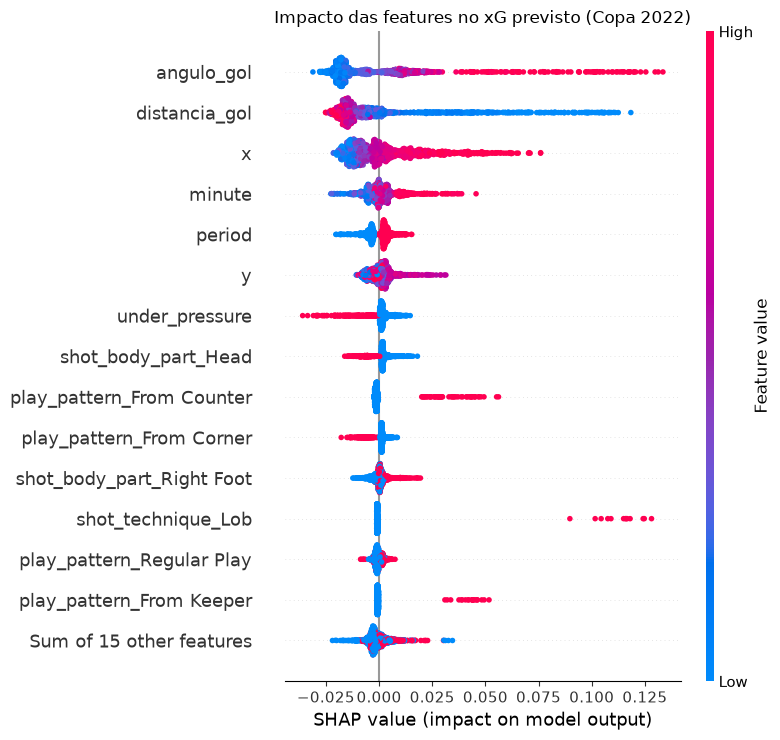

In [4]:
shap.plots.beeswarm(shap_values_gol, max_display=15, show=False)
plt.title("Impacto das features no xG previsto (Copa 2022)")
plt.tight_layout()
plt.show()

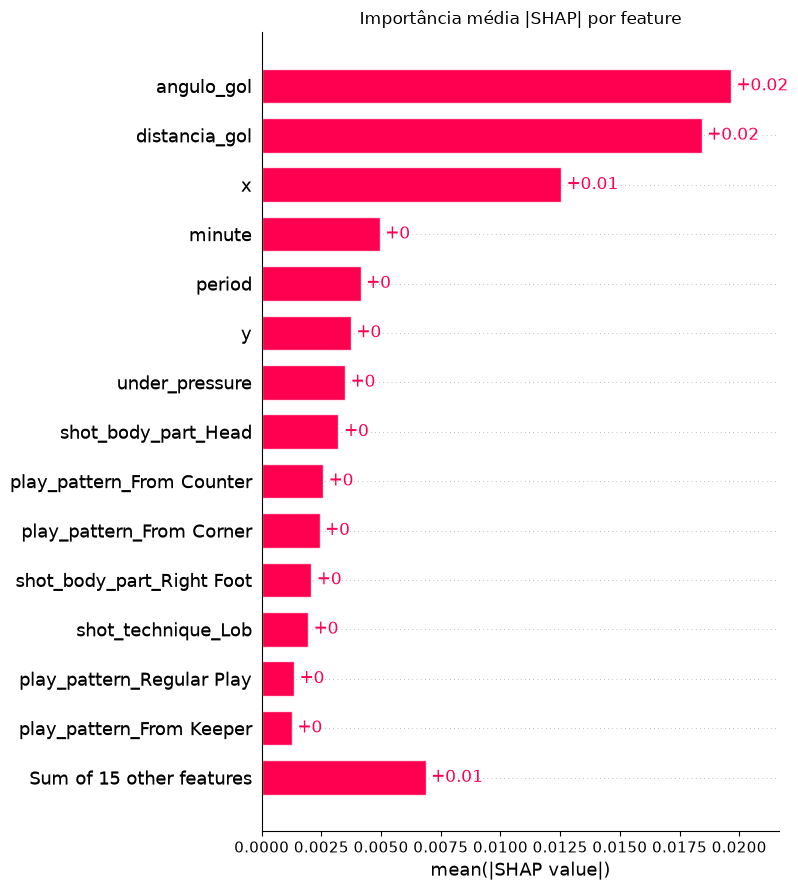

In [5]:
shap.plots.bar(shap_values_gol, max_display=15, show=False)
plt.title("Importância média |SHAP| por feature")
plt.tight_layout()
plt.show()

## 5. Dependência das duas features geométricas principais

`distancia_gol` e `angulo_gol` são, pela literatura de xG, as features mais determinantes. Os gráficos de dependência mostram como o valor SHAP varia em função do valor da feature (e da interação automática detectada pelo SHAP).

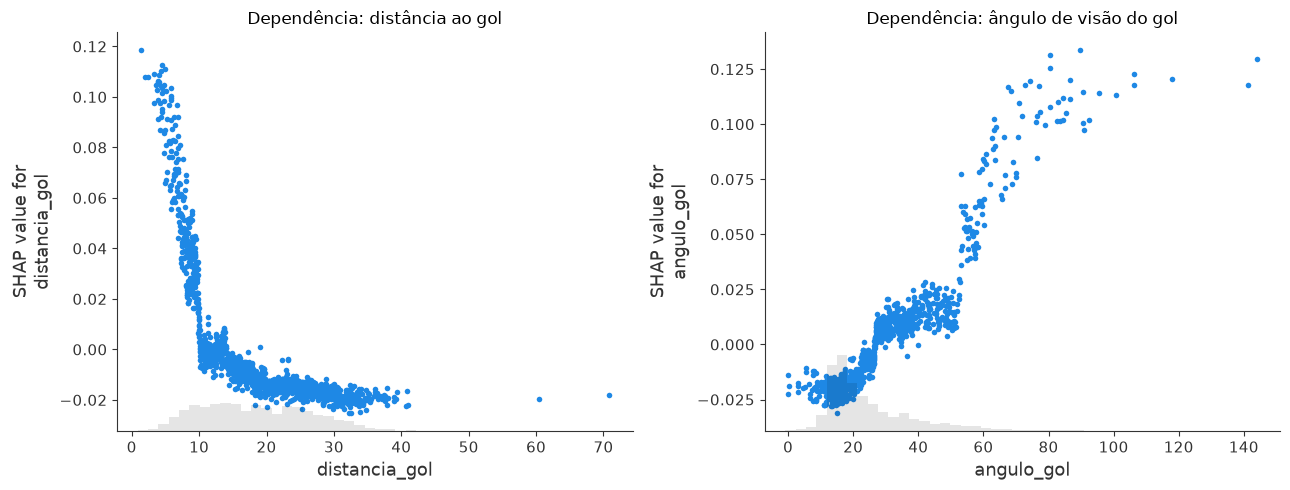

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
shap.plots.scatter(shap_values_gol[:, "distancia_gol"], ax=axes[0], show=False)
axes[0].set_title("Dependência: distância ao gol")
shap.plots.scatter(shap_values_gol[:, "angulo_gol"], ax=axes[1], show=False)
axes[1].set_title("Dependência: ângulo de visão do gol")
plt.tight_layout()
plt.show()

## 6. Explicando chutes individuais

Comparamos o chute com **maior probabilidade de gol prevista** e o chute com **maior erro do modelo** (previu baixo xG, mas resultou em gol) — casos úteis para discutir limitações do modelo no artigo.

In [7]:
proba_gol = modelo_campeao.predict_proba(X_teste_principal)[:, 1]

indice_maior_xg = int(np.argmax(proba_gol))

indices_gol_real = np.where(y_teste_principal.to_numpy() == 1)[0]
indice_maior_surpresa = int(indices_gol_real[np.argmin(proba_gol[indices_gol_real])])

print(f"Chute com maior xG previsto: índice {indice_maior_xg}, xG = {proba_gol[indice_maior_xg]:.3f}")
print(
    f"Gol com menor xG previsto (maior 'surpresa'): índice {indice_maior_surpresa}, "
    f"xG = {proba_gol[indice_maior_surpresa]:.3f}"
)

Chute com maior xG previsto: índice 603, xG = 0.469
Gol com menor xG previsto (maior 'surpresa'): índice 59, xG = 0.029


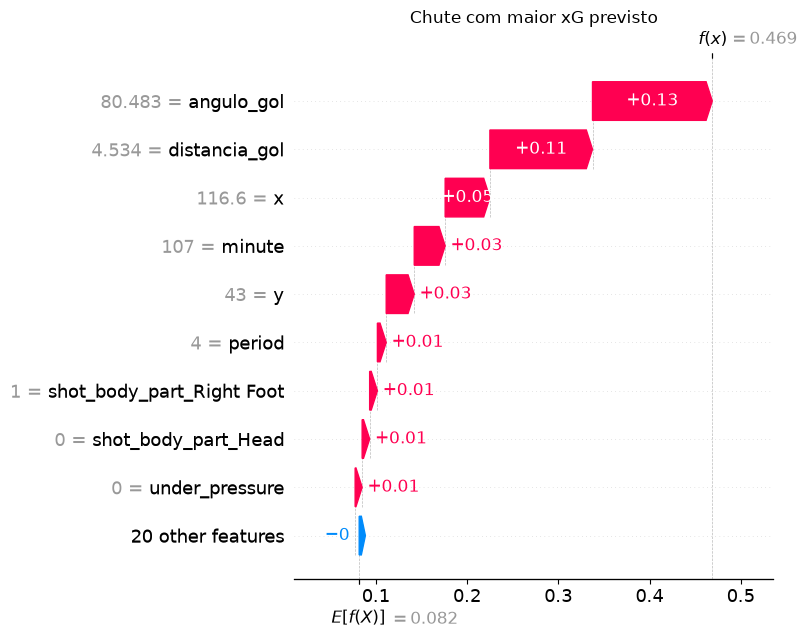

In [8]:
shap.plots.waterfall(shap_values_gol[indice_maior_xg], show=False)
plt.title("Chute com maior xG previsto")
plt.tight_layout()
plt.show()

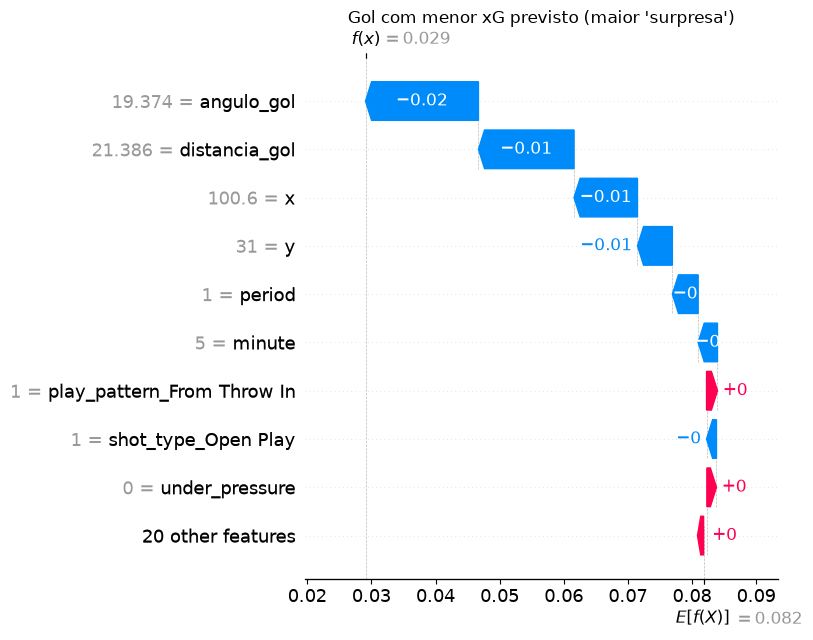

In [9]:
shap.plots.waterfall(shap_values_gol[indice_maior_surpresa], show=False)
plt.title("Gol com menor xG previsto (maior 'surpresa')")
plt.tight_layout()
plt.show()

## 7. Robustez da interpretação: teste externo (Euro 2020)

Repetimos a importância global no Euro 2020 para verificar se o comportamento do modelo (quais features pesam mais) se mantém estável entre torneios diferentes — evidência de que o modelo aprendeu um padrão geométrico geral, e não algo específico da Copa 2022.

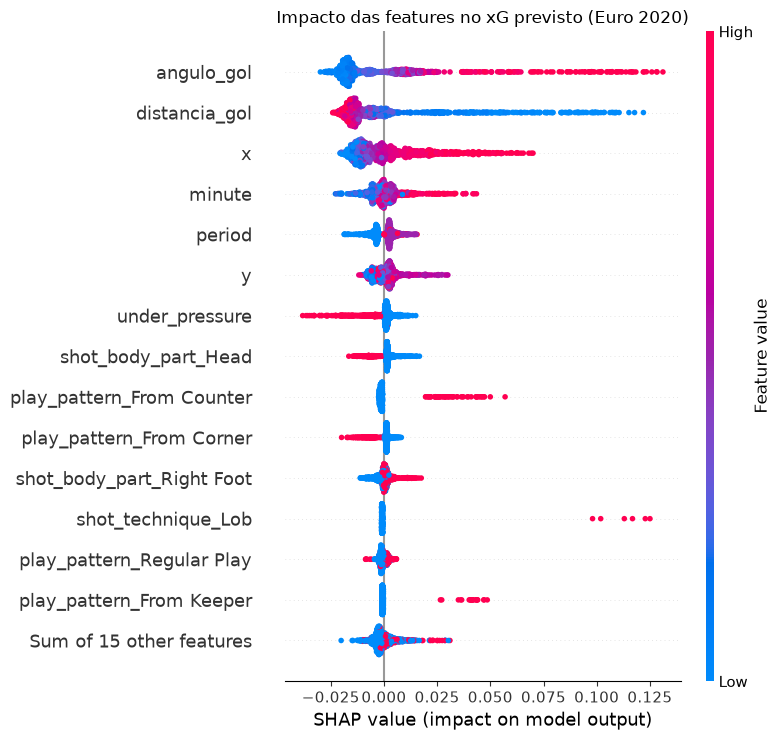

In [10]:
shap_values_euro = explainer(X_teste_externo)[:, :, 1]

shap.plots.beeswarm(shap_values_euro, max_display=15, show=False)
plt.title("Impacto das features no xG previsto (Euro 2020)")
plt.tight_layout()
plt.show()

## 8. Conclusão

- `distancia_gol` e `angulo_gol` dominam a decisão do modelo em ambos os torneios, confirmando a consistência do comportamento geométrico esperado para xG.
- A ordem de importância das demais features (parte do corpo, situação de jogo, pressão) se mantém razoavelmente estável entre Copa 2022 e Euro 2020.
- Os casos individuais (waterfall plots) são úteis para ilustrar, no artigo, tanto o comportamento esperado do modelo quanto suas limitações (chutes de baixa probabilidade que resultam em gol).

Próximo passo: integrar o modelo campeão (Random Forest) ao dashboard Streamlit (`dashboard/app.py`).